In [21]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [22]:
# 1. Hàm load dữ liệu từ folder
def load_face_data(folder_path="./cropped_datasets"):
    data = []
    labels = []
    label_map = {}
    current_label = 0

    for name in sorted(os.listdir(folder_path)):
        person_path = os.path.join(folder_path, name)
        if not os.path.isdir(person_path):
            continue
        label_map[name] = current_label
        for filename in os.listdir(person_path):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                path = os.path.join(person_path, filename)
                img = cv2.imread(path)
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                resized = cv2.resize(gray, (100, 100))
                data.append(resized)
                labels.append(current_label)
        current_label += 1

    return np.array(data), np.array(labels), label_map

In [23]:
# 2. Load và xử lý dữ liệu
data, labels, label_map = load_face_data("./cropped_datasets")
data = data.astype("float32") / 255.0  # Chuẩn hóa
data = np.expand_dims(data, axis=-1)   # Thêm kênh (100,100) -> (100,100,1)


In [24]:
# 3. Encode nhãn
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

In [25]:
# 4. Tách train/test
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

In [26]:
# 5. Xây dựng mô hình CNN
model = Sequential()
model.add(Conv2D(32, (3,3), padding="same", input_shape=(100,100,1)))
model.add(Activation("relu"))
model.add(Conv2D(32, (3,3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(len(label_map)))
model.add(Activation("softmax"))

c:\Users\DELL\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,822,310 (18.40 MB)

 Trainable params: 4,822,310 (18.40 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 6. Compile model
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=0.0005), metrics=["accuracy"])


In [29]:
# 9. Dữ liệu tăng cường
aug = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=True
)

In [30]:
import math


steps = math.ceil(len(X_train) / 5)


from sklearn.utils.class_weight import compute_class_weight

# Phục hồi nhãn gốc từ one-hot
labels_raw = np.argmax(labels, axis=1)
class_weights = compute_class_weight("balanced", classes=np.unique(labels_raw), y=labels_raw)
class_weight_dict = dict(enumerate(class_weights))

from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

history = model.fit(
    aug.flow(X_train, y_train, batch_size=5),
    validation_data=(X_test, y_test),
    steps_per_epoch=steps,
    epochs=50,
    callbacks=[lr_callback],
    class_weight=class_weight_dict
)


Epoch 1/50


c:\Users\DELL\miniconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.2311 - loss: 1.7856 - val_accuracy: 0.7481 - val_loss: 0.8996 - learning_rate: 5.0000e-04
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6457 - loss: 0.9980 - val_accuracy: 0.8931 - val_loss: 0.3604 - learning_rate: 5.0000e-04
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8256 - loss: 0.5033 - val_accuracy: 0.9008 - val_loss: 0.3211 - learning_rate: 5.0000e-04
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8392 - loss: 0.5526 - val_accuracy: 0.9313 - val_loss: 0.2311 - learning_rate: 5.0000e-04
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8910 - loss: 0.3232 - val_accuracy: 0.9542 - val_loss: 0.1144 - learning_rate: 5.0000e-04
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9375 - loss: 0.2557 - val_accuracy: 0.9618 - val_loss: 0.1441 - learning_rate: 5.0000e-04
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.89

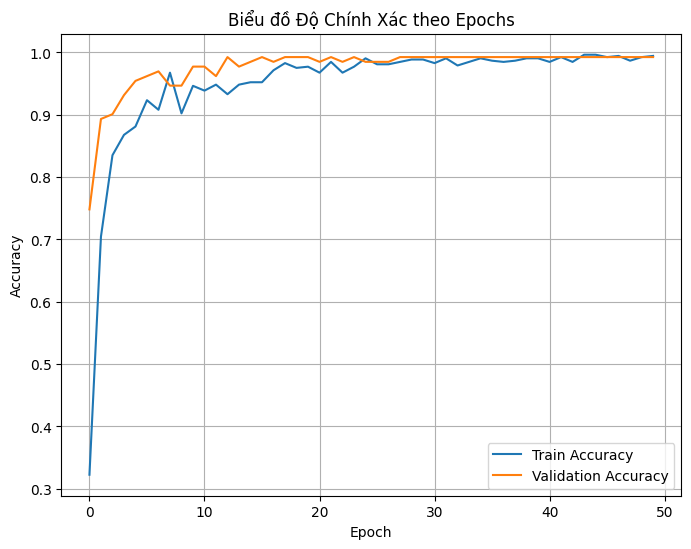

In [31]:
import matplotlib.pyplot as plt

# 1. Vẽ accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Biểu đồ Độ Chính Xác theo Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


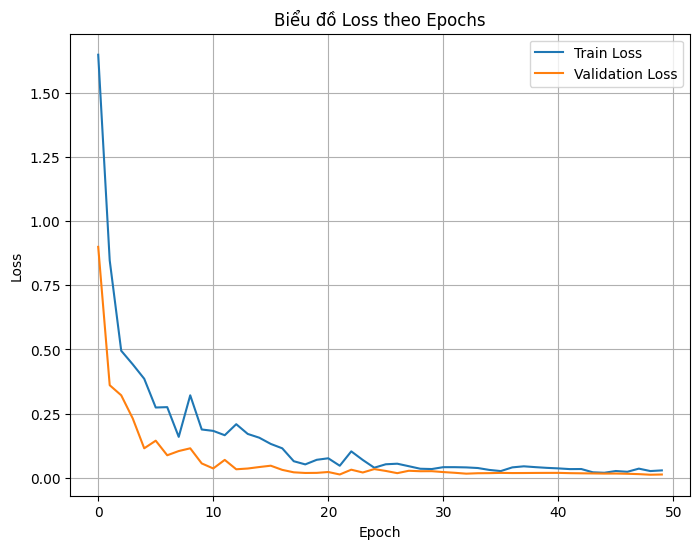

In [32]:
# 2. Vẽ loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Biểu đồ Loss theo Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [33]:
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy tổng trên tập test: {test_accuracy * 100:.2f}%")


Accuracy tổng trên tập test: 99.24%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


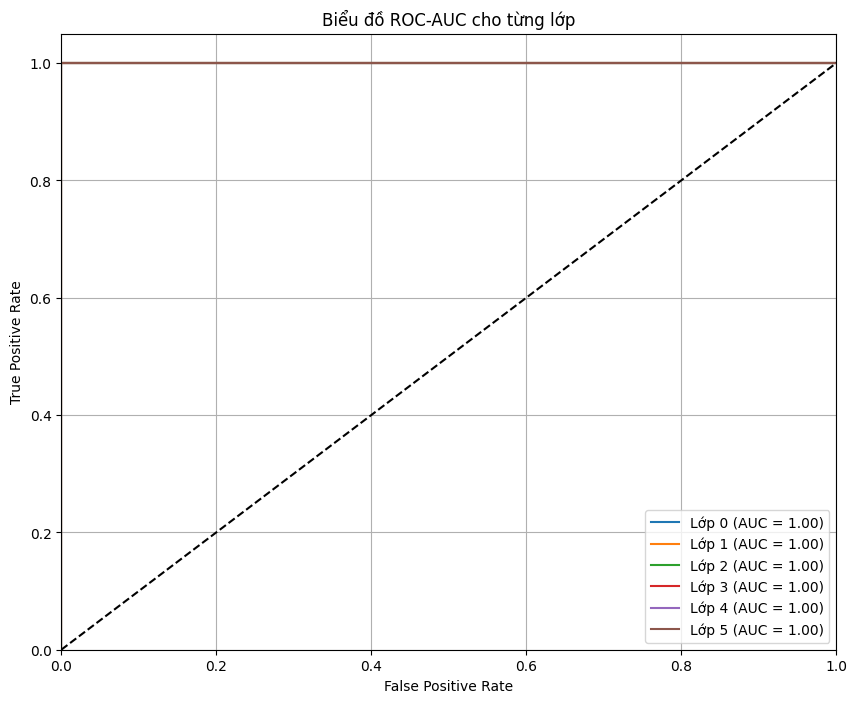

In [34]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Dự đoán xác suất
y_pred_proba = model.predict(X_test)

# Số lớp
n_classes = y_test.shape[1]

# Nếu nhãn chưa one-hot thì cần label_binarize (ở đây bạn đã one-hot rồi nên ok)

# Vẽ ROC cho từng lớp
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Lớp {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Đường chéo
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Biểu đồ ROC-AUC cho từng lớp')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
